# Phase 11 – Binary Classification Outputs

This notebook visualize binary classification outputs generated by the C++ ML Core practical workflow.

It reads exported CSV files only. It does **not** train models or reimplement model logic in Python.

Input files:

```txt
outputs/practical-exercises/binary-classification/metrics.csv
outputs/practical-exercises/binary-classification/predictions.csv
outputs/practical-exercises/binary-classification/probabilities.csv
outputs/practical-exercises/binary-classification/decision_scores.csv
outputs/practical-exercises/binary-classification/loss_history.csv
````

Dataset:

```txt
NASA KC1 Software Defect Prediction
```

Target:

```txt
defects
```

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../../outputs/practical-exercises/binary-classification")

metrics_path = OUTPUT_DIR / "metrics.csv"
predictions_path = OUTPUT_DIR / "predictions.csv"
probabilities_path = OUTPUT_DIR / "probabilities.csv"
decision_scores_path = OUTPUT_DIR / "decision_scores.csv"
loss_history_path = OUTPUT_DIR / "loss_history.csv"

required_paths = [
    metrics_path,
    predictions_path,
    probabilities_path,
    decision_scores_path,
    loss_history_path,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required output file: {path}")

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
probabilities = pd.read_csv(probabilities_path)
decision_scores = pd.read_csv(decision_scores_path)
loss_history = pd.read_csv(loss_history_path)

print("metrics", metrics.shape)
print("predictions", predictions.shape)
print("probabilities", probabilities.shape)
print("decision_scores", decision_scores.shape)
print("loss_history", loss_history.shape)

metrics (24, 7)
predictions (960, 9)
probabilities (640, 9)
decision_scores (320, 8)
loss_history (450, 7)


## Metrics table

The metrics file contains one row per model and metric.

For binary classification, the main metrics are:

```txt
accuracy
precision
recall
f1
```

Because the KC1 dataset is imbalanced, accuracy should not be interpreted alone.

Precision, recall, and F1 are more informative for the minority defect class.

In [3]:
metrics_pivot = (
    metrics
    .pivot_table(
        index="model",
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

metrics_pivot

metric,model,accuracy,f1,precision,recall
0,DecisionTreeClassifier,0.63750,0.408163,0.277778,0.769231
1,GaussianNaiveBayes,0.85000,0.520000,0.541667,0.500000
2,LinearSVM,0.84375,0.242424,0.571429,0.153846
3,LogisticRegression,0.82500,0.300000,0.428571,0.230769
4,RandomForestClassifier,0.71250,0.510638,0.352941,0.923077
5,TinyMLPBinaryClassifier,0.84375,0.137931,0.666667,0.076923


## Metric comparison plots

Higher is better for all displayed binary classification metrics:

```txt
accuracy
precision
recall
f1
```

For imbalanced defect prediction, the most important metrics are usually recall and F1.

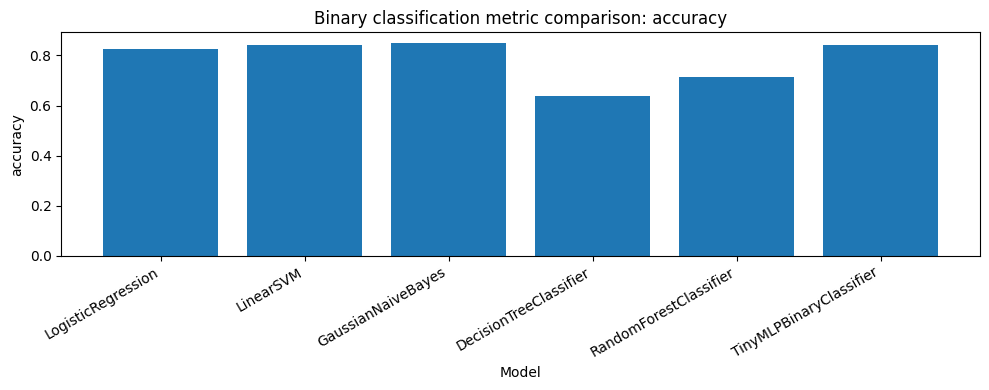

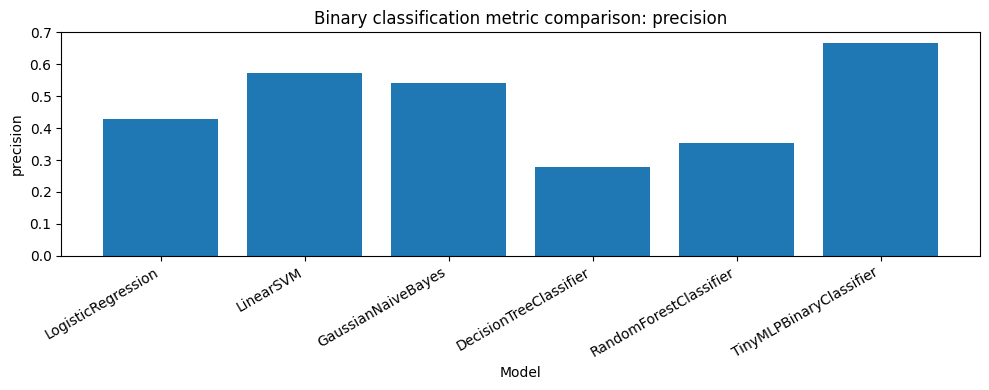

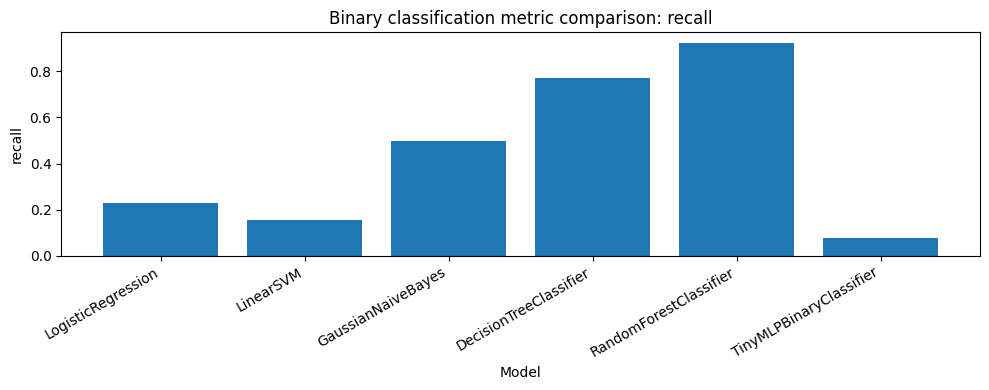

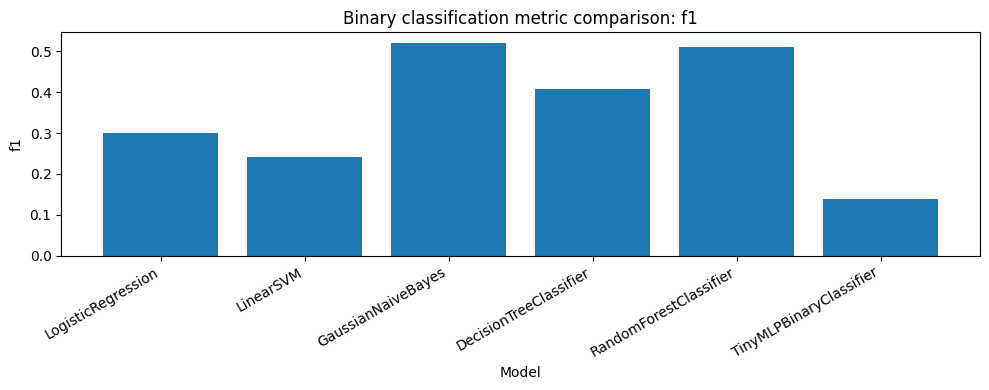

In [4]:
for metric_name in ["accuracy", "precision", "recall", "f1"]:
    subset = metrics[metrics["metric"] == metric_name].copy()

    plt.figure(figsize=(10, 4))
    plt.bar(subset["model"], subset["value"])
    plt.title(f"Binary classification metric comparison: {metric_name}")
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Prediction correctness by model

The predictions file contains:

```txt
y_true
y_pred
correct
```

This section compares how many test samples each model predicted correctly.

In [5]:
correctness_summary = (
    predictions
    .groupby(["model", "correct"])
    .size()
    .reset_index(name="count")
)

correctness_summary

,model,correct,count
0,DecisionTreeClassifier,0,58
1,DecisionTreeClassifier,1,102
2,GaussianNaiveBayes,0,24
3,GaussianNaiveBayes,1,136
4,LinearSVM,0,25
5,LinearSVM,1,135
6,LogisticRegression,0,28
7,LogisticRegression,1,132
8,RandomForestClassifier,0,46
9,RandomForestClassifier,1,114


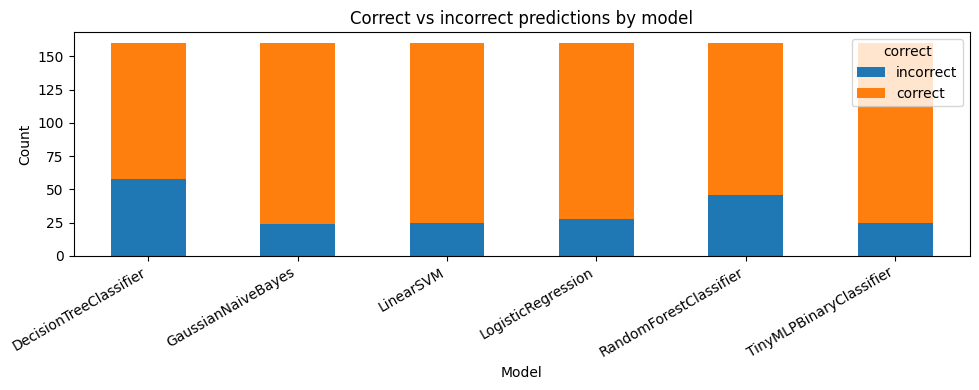

In [7]:
correctness_pivot = (
    correctness_summary
    .pivot_table(
        index="model",
        columns="correct",
        values="count",
        fill_value=0,
    )
)

correctness_pivot = correctness_pivot.rename(columns={0: "incorrect", 1: "correct"})

correctness_pivot.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Correct vs incorrect predictions by model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Probability distribution

The probability file contains:

```txt
probability_class_0
probability_class_1
```

For binary defect prediction:

```txt
class 0 = no defect
class 1 = no defect
```

The ditribution of `probability_class_1` helps show whether a model is confident about detecting positive defect cases or mostly predicts low positive probability.

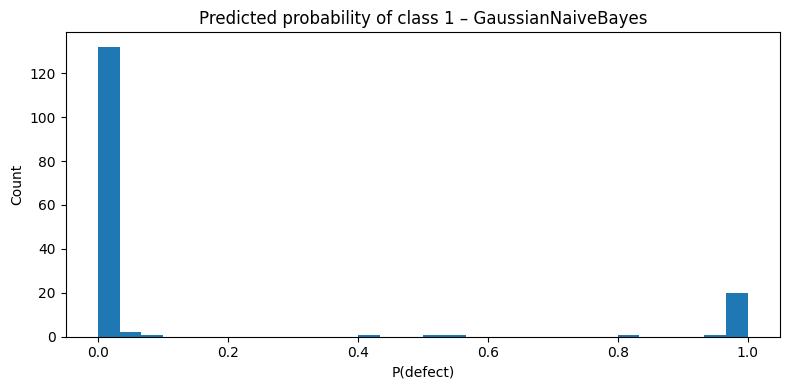

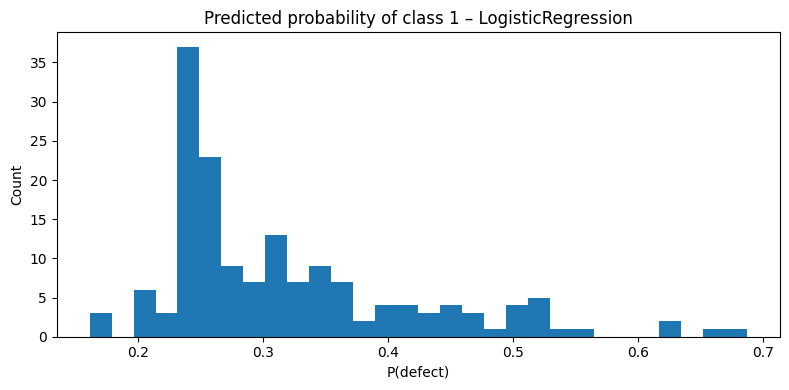

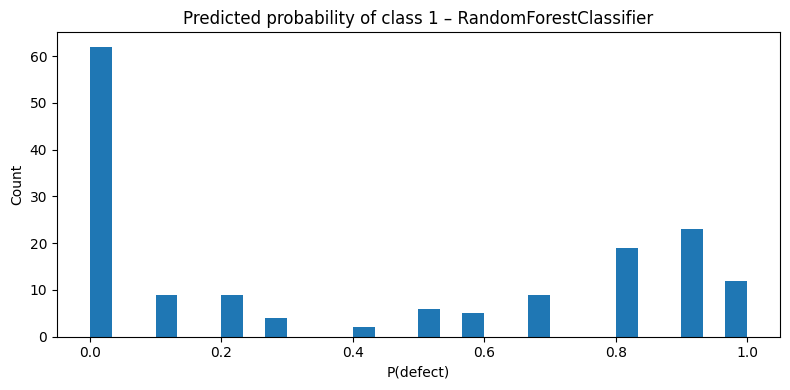

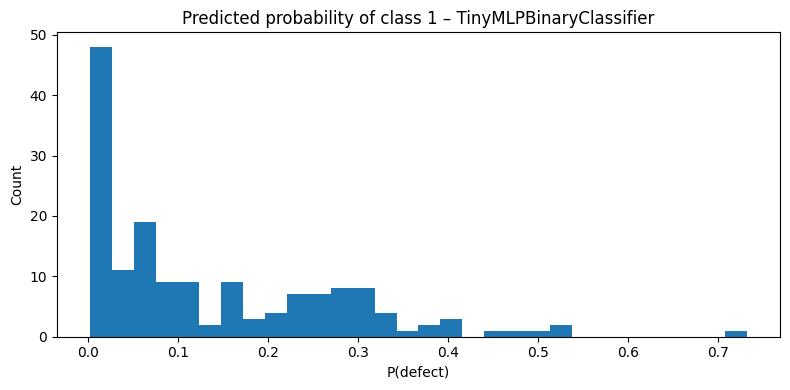

In [8]:
for model_name, subset in probabilities.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.hist(subset["probability_class_1"], bins=30)
    plt.title(f"Predicted probability of class 1 – {model_name}")
    plt.xlabel("P(defect)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Probability distributions by true class

This plot separates predicted positive-class probabilities by the true label.

A useful classifier should generally assign higher `P(defect)` to true positive samples than to true negative samples.

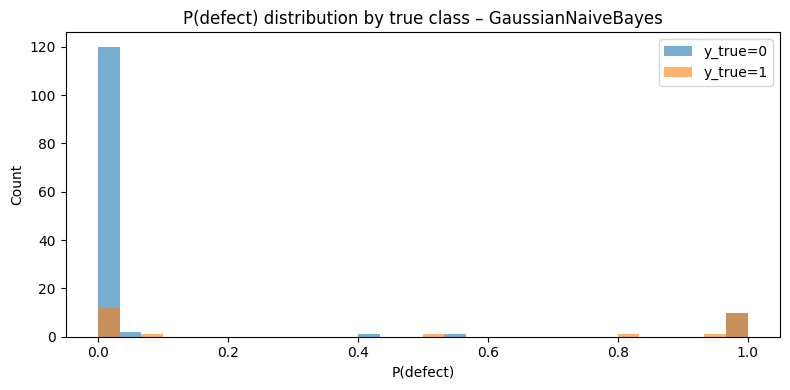

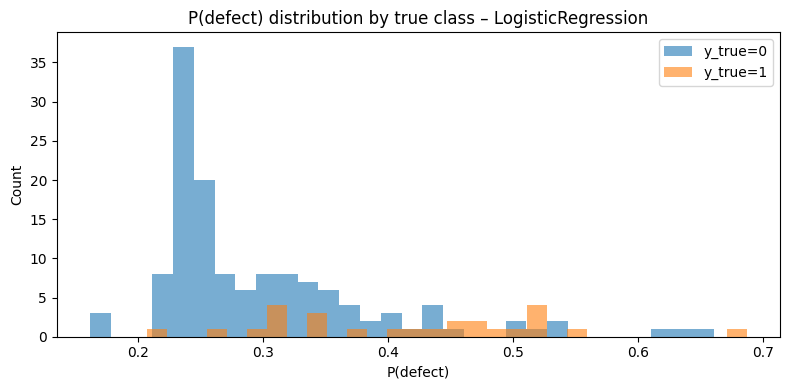

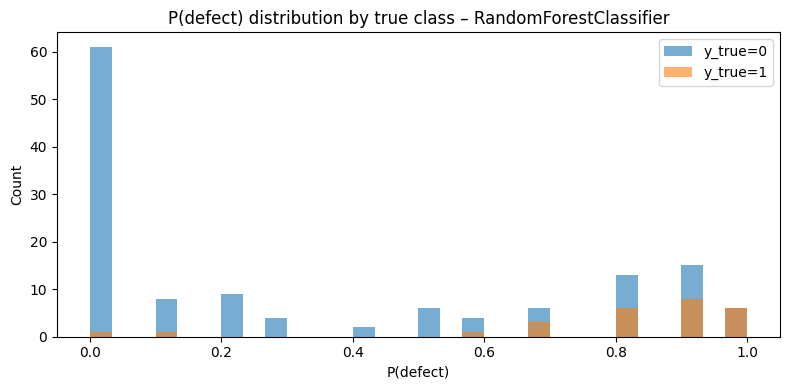

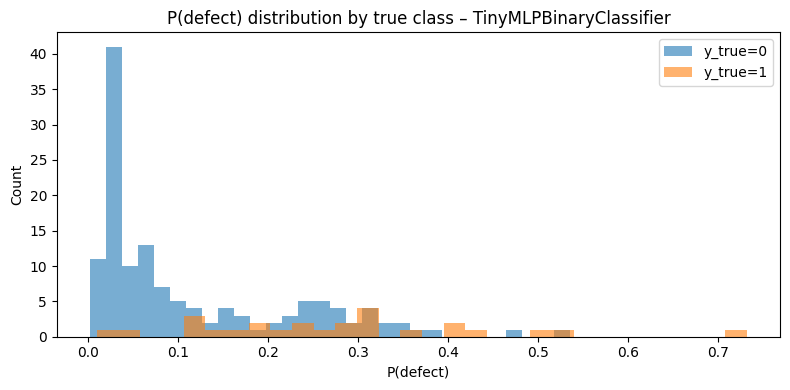

In [9]:
for model_name, subset in probabilities.groupby("model"):
    plt.figure(figsize=(8, 4))

    for true_label in sorted(subset["y_true"].unique()):
        label_subset = subset[subset["y_true"] == true_label]
        plt.hist(
            label_subset["probability_class_1"],
            bins=30,
            alpha=0.6,
            label=f"y_true={int(true_label)}",
        )

    plt.title(f"P(defect) distribution by true class – {model_name}")
    plt.xlabel("P(defect)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Decision scores

Decision scores are available only for models that expose raw decision values.

In this workflow, that includes:

```txt
LogisticRegression
LinearSVM
```

Decision scores are useful because they show the margin or raw confidence before thresholding.

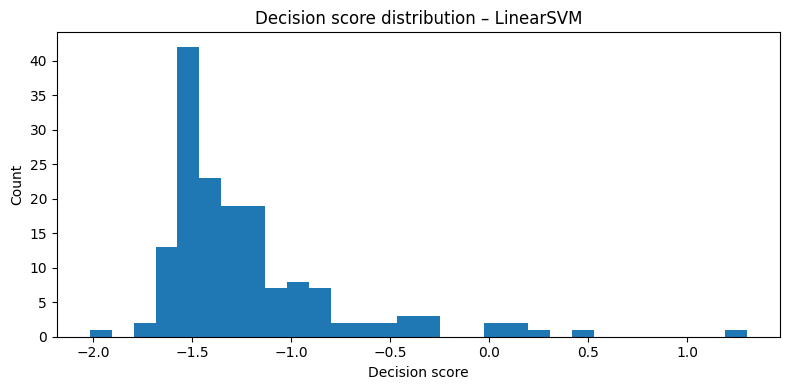

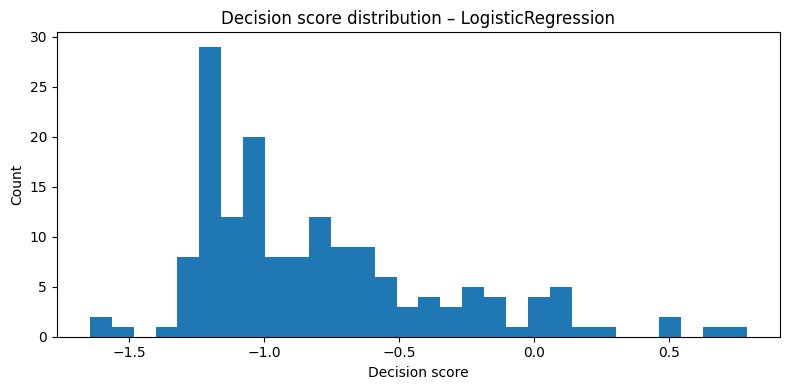

In [10]:
for model_name, subset in decision_scores.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.hist(subset["decision_score"], bins=30)
    plt.title(f"Decision score distribution – {model_name}")
    plt.xlabel("Decision score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

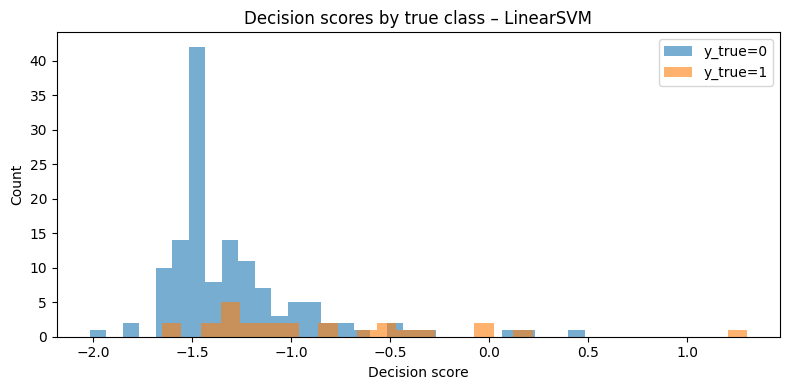

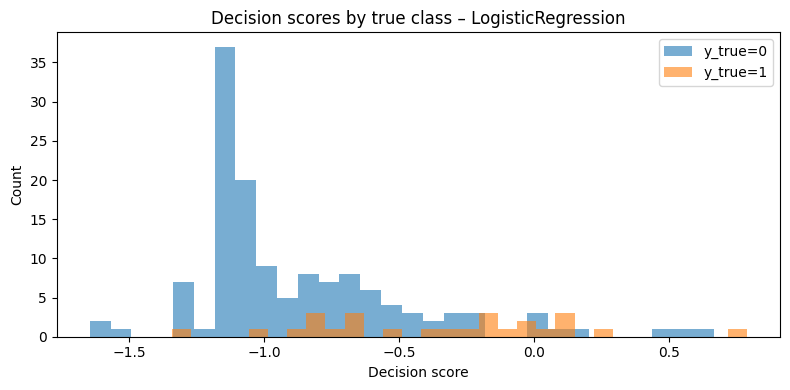

In [11]:
for model_name, subset in decision_scores.groupby("model"):
    plt.figure(figsize=(8, 4))

    for true_label in sorted(subset["y_true"].unique()):
        label_subset = subset[subset["y_true"] == true_label]
        plt.hist(
            label_subset["decision_score"],
            bins=30,
            alpha=0.6,
            label=f"y_true={int(true_label)}",
        )

    plt.title(f"Decision scores by true class – {model_name}")
    plt.xlabel("Decision score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Loss history

Loss history is available for iterative trainable models.

In this workflow, it can include:

```txt
LogisticRegression
LinearSVM
TinyMLPBinaryClassifier
```

The loss curves help verify whether training is stable.

In [12]:
loss_history.head()

,run_id,workflow,dataset,model,split,iteration,loss
0,logistic_regression_baseline,binary_classification,nasa_kc1_software_defects,LogisticRegression,train,0,0.693147
1,logistic_regression_baseline,binary_classification,nasa_kc1_software_defects,LogisticRegression,train,1,0.690355
2,logistic_regression_baseline,binary_classification,nasa_kc1_software_defects,LogisticRegression,train,2,0.687685
3,logistic_regression_baseline,binary_classification,nasa_kc1_software_defects,LogisticRegression,train,3,0.685129
4,logistic_regression_baseline,binary_classification,nasa_kc1_software_defects,LogisticRegression,train,4,0.682679


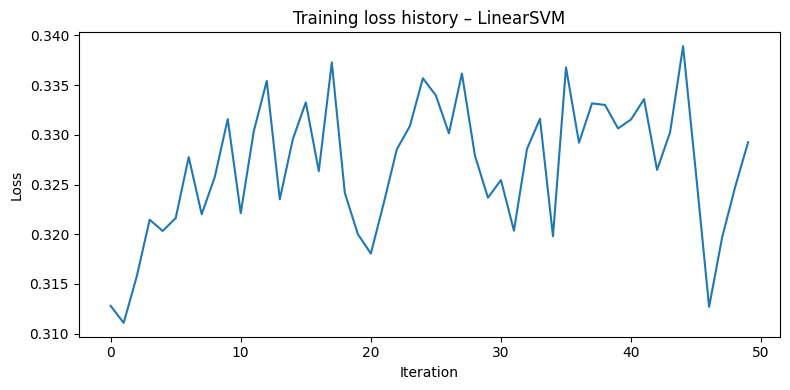

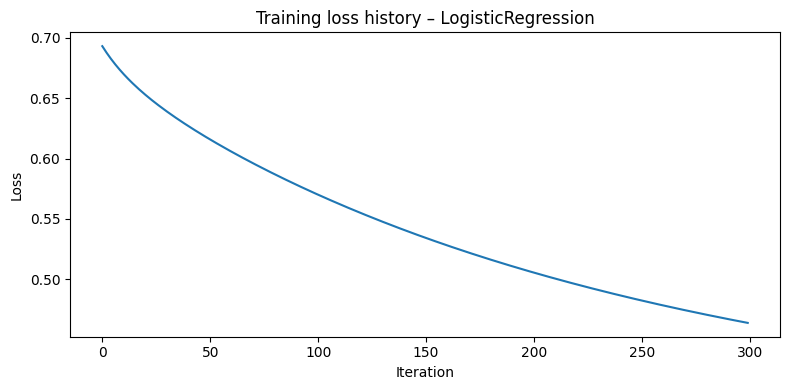

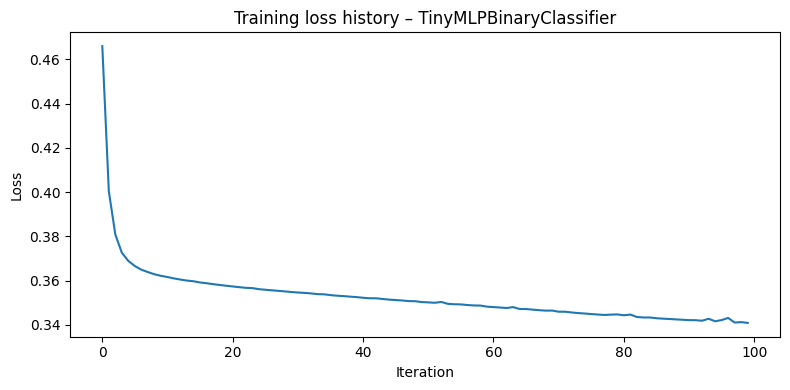

In [13]:
for model_name, subset in loss_history.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.plot(subset["iteration"], subset["loss"])
    plt.title(f"Training loss history – {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()

## Interpretation notes

This notebook is for visualization only.

The KC1 software defect dataset is imbalanced. A model can achieve high accuracy while detecting very few defective modules.

Important interpretation rules:

```txt
High accuracy + low recall:
  model is mostly predicting the majority class

High recall + low precision:
  model detects many defects but also creates many false alarms

Higher F1:
  better balance between precision and recall
```